# 手寫阿拉伯數字辨識 專家模式

## 載入套件

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torch
from skimage import io
from skimage.transform import resize
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

## 設定參數

In [2]:
# 設定參數
PATH_DATASETS = "data" # 預設路徑
BATCH_SIZE = 1024  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 步驟1：載入 MNIST 手寫阿拉伯數字資料

In [3]:
mnist = tf.keras.datasets.mnist

# 下載 MNIST 手寫阿拉伯數字 訓練資料
train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=transforms.ToTensor())

# 下載測試資料
test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=transforms.ToTensor())

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


## 步驟2：資料清理，此步驟無需進行

## 步驟3：特徵工程，此步驟無需進行

## 步驟4：資料分割，此步驟無需進行，載入MNIST資料時，已經切割好了

## 步驟5：建立模型結構

In [4]:
# 建立模型
class Net(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 256)  # 完全連接層
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, 10)  # 完全連接層
        self.dropout2 = nn.Dropout(0.2)

    def forward(self, x: torch.Tensor):
        # 完全連接層 + dropout + 完全連接層 + dropout + log_softmax
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.dropout2(x)
        output = F.log_softmax(x, dim=1)
        return output


# 建立模型物件
model = Net().to(device)

## 設定模型及學習率組態

## 步驟6：結合訓練資料及模型，進行模型訓練

In [5]:
epochs = 5
lr = 0.1

# 建立 DataLoader
train_loader = DataLoader(train_ds, batch_size=600)

# 設定優化器(optimizer)
optimizer = optim.Adam(model.parameters(), lr=lr)

model.train()
loss_list = []
for epoch in range(1, epochs + 1):
    data: torch.Tensor
    target: torch.Tensor
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output: torch.Tensor = model(data)
        # 計算損失(loss)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 10 == 0:
            loss_list.append(loss.item())
            batch = (batch_idx + 10) * len(data)
            data_count = len(train_ds)
            percentage = 100.0 * (batch_idx + 10) / len(train_loader)
            print(f'Epoch {epoch}: [{batch:5d} / {data_count}] ({percentage:.0f} %)  Loss: {loss.item():.6f}')

Epoch 1: [ 6000 / 60000] (10 %)  Loss: 2.297225
Epoch 1: [12000 / 60000] (20 %)  Loss: 48.284081
Epoch 1: [18000 / 60000] (30 %)  Loss: 20.756721
Epoch 1: [24000 / 60000] (40 %)  Loss: 10.594289
Epoch 1: [30000 / 60000] (50 %)  Loss: 9.945915
Epoch 1: [36000 / 60000] (60 %)  Loss: 7.372836
Epoch 1: [42000 / 60000] (70 %)  Loss: 5.148095
Epoch 1: [48000 / 60000] (80 %)  Loss: 5.307695
Epoch 1: [54000 / 60000] (90 %)  Loss: 3.484373
Epoch 1: [60000 / 60000] (100 %)  Loss: 3.243845
Epoch 2: [ 6000 / 60000] (10 %)  Loss: 2.421895
Epoch 2: [12000 / 60000] (20 %)  Loss: 1.524147
Epoch 2: [18000 / 60000] (30 %)  Loss: 3.059054
Epoch 2: [24000 / 60000] (40 %)  Loss: 1.884021
Epoch 2: [30000 / 60000] (50 %)  Loss: 2.348822
Epoch 2: [36000 / 60000] (60 %)  Loss: 1.959519
Epoch 2: [42000 / 60000] (70 %)  Loss: 1.561762
Epoch 2: [48000 / 60000] (80 %)  Loss: 2.049382
Epoch 2: [54000 / 60000] (90 %)  Loss: 1.423547
Epoch 2: [60000 / 60000] (100 %)  Loss: 1.612081
Epoch 3: [ 6000 / 60000] (10 %)  Lo

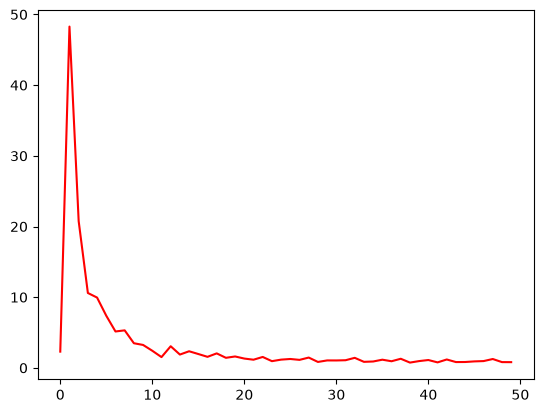

In [6]:
# 對訓練過程的損失繪圖
plt.plot(loss_list, 'r')

## 步驟7：評分(Score Model)

In [7]:
# 建立 DataLoader
test_loader = DataLoader(test_ds, batch_size=600)

model.eval()
test_loss = 0
correct = 0
with torch.no_grad():
    data: torch.Tensor
    target: torch.Tensor
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output: torch.Tensor = model(data)

        # sum up batch loss
        test_loss += F.nll_loss(output, target, reduction='sum').item()

        # 預測
        pred = output.argmax(dim=1, keepdim=True)

        # 正確筆數
        correct += pred.eq(target.view_as(pred)).sum().item()

data_count = len(test_ds.data)
# 平均損失
test_loss /= data_count
# 顯示測試結果
percentage = 100.0 * correct / data_count
print(f'平均損失: {test_loss:.4f}, 準確率: {correct}/{data_count} ({percentage:.0f}%)\n')

平均損失: 0.6132, 準確率: 8788/10000 (88%)



In [8]:
# 實際預測 20 筆資料
predictions = []
with torch.no_grad():
    for i in range(20):
        data: torch.Tensor = test_ds[i][0]
        data = data.reshape(1, *data.shape).to(device)
        output = torch.argmax(model(data), dim=-1)
        predictions.append(str(output.item()))

# 比對
print('actual    :', test_ds.targets[0:20].numpy())
print('prediction: ', ' '.join(predictions[0:20]))

actual    : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
prediction:  7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 5 4


## 步驟8：評估，暫不進行

## 步驟9：模型佈署

## 步驟10：新資料預測

In [9]:
# 使用小畫家，繪製 0~9，實際測試看看
# 讀取影像並轉為單色
for i in range(10):
    uploaded_file = f'./myDigits/{i}.png'
    image1 = io.imread(uploaded_file, as_gray=True)

    # 縮為 (28, 28) 大小的影像
    image_resized = resize(image1, (28, 28), anti_aliasing=True)    
    X1 = np.asarray(image_resized).reshape(1, 28, 28)  # / 255.0

    # 反轉顏色，顏色0為白色，與 RGB 色碼不同，它的 0 為黑色
    X1 = torch.FloatTensor(1-X1).to(device)

    # 預測
    predictions = torch.softmax(model(X1), dim=1)
    # print(np.around(predictions.cpu().detach().numpy(), 2))
    print(f'actual/prediction: {i} {np.argmax(predictions.detach().cpu().numpy())}')

actual/prediction: 0 9
actual/prediction: 1 1
actual/prediction: 2 2
actual/prediction: 3 7
actual/prediction: 4 7
actual/prediction: 5 5
actual/prediction: 6 6
actual/prediction: 7 7
actual/prediction: 8 8
actual/prediction: 9 8
